In [63]:
import numpy as np
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm
from utils import simulate_bagging_and_ijk_var_calculation
import pandas as pd

In [64]:

####### Simulation parameters  #########
n_x = 1000
n_sim = 2000
portion_non_zero_weights = 0.5
var_x = 1
seed = 42

B_values = [500,1000,2000,4000] #, 2000, 4000, 10000]  # Different B values

# Prepare to collect results
results = []

# Loop over each B value
for B in B_values:
    print(f"Running simulations for B = {B}")
    # run simulation
    with ProcessPoolExecutor() as executor:
        rng = np.random.default_rng(seed)
        weights = np.zeros(n_x)

        m = int(n_x * portion_non_zero_weights)         # number of non-zero weights
        x_sim = rng.normal(0, var_x**0.5, (n_sim, n_x)) # simulate n_sim data-sets
        weights[:m] = 1 / m                             # weights for the first m variables = 1/m , else 0

        ijk_jahn = np.zeros(n_sim)
        ijk_wager = np.zeros(n_sim)
        ijk_jahn_u = np.zeros(n_sim)
        ijk_wager_u = np.zeros(n_sim)
        jk_wager = np.zeros(n_sim)
        jk_wager_u = np.zeros(n_sim)

        futures = [
            executor.submit(
                simulate_bagging_and_ijk_var_calculation,
                x1=x_sim[i],
                B=B,
                sim_i=i,
                seed=seed,
                weights=weights,
                m=m,
            )
            for i in range(n_sim)
        ]

        for i, future in enumerate(tqdm(futures, desc=f"Simulations for B={B}", unit="simulation")):
            _ijk_jahn, _ijk_jahn_u, _ijk_wager, _ijk_wager_u, _jk_wager, _jk_wager_u = future.result()

            # speichere relative biases
            true_var = var_x / m
            ijk_jahn[i] = (_ijk_jahn - true_var) / true_var * 100
            ijk_jahn_u[i] = ((_ijk_jahn-_ijk_jahn_u) - true_var) / true_var * 100
            ijk_wager[i] = (_ijk_wager - true_var) / true_var * 100
            ijk_wager_u[i] = ((_ijk_wager-_ijk_wager_u) - true_var) / true_var * 100
            jk_wager[i] = (_jk_wager - true_var) / true_var * 100
            jk_wager_u[i] = ((_jk_wager-_jk_wager_u) - true_var) / true_var * 100

            # Ergebnisse in DataFrame speichern
        df_results = pd.DataFrame({
            'ijk_jahn': ijk_jahn,
            'ijk_jahn_u': ijk_jahn_u,
            'ijk_wager': ijk_wager,
            'ijk_wager_u': ijk_wager_u,
            'jk_wager': jk_wager,
            'jk_wager_u': jk_wager_u,
            'true_variance': true_var
        })

        # CSV-Datei schreiben
        df_results.to_csv(f'simulation_results_B_{B}.csv', index=False)

        print(f"Results saved to simulation_results_B_{B}.csv")


Running simulations for B = 500


Simulations for B=500: 100%|██████████| 2000/2000 [00:14<00:00, 134.63simulation/s]


Results saved to simulation_results_B_500.csv
Running simulations for B = 1000


Simulations for B=1000: 100%|██████████| 2000/2000 [00:29<00:00, 67.87simulation/s]


Results saved to simulation_results_B_1000.csv
Running simulations for B = 2000


Simulations for B=2000: 100%|██████████| 2000/2000 [00:54<00:00, 36.46simulation/s]


Results saved to simulation_results_B_2000.csv
Running simulations for B = 4000


Simulations for B=4000: 100%|██████████| 2000/2000 [01:44<00:00, 19.06simulation/s]


Results saved to simulation_results_B_4000.csv


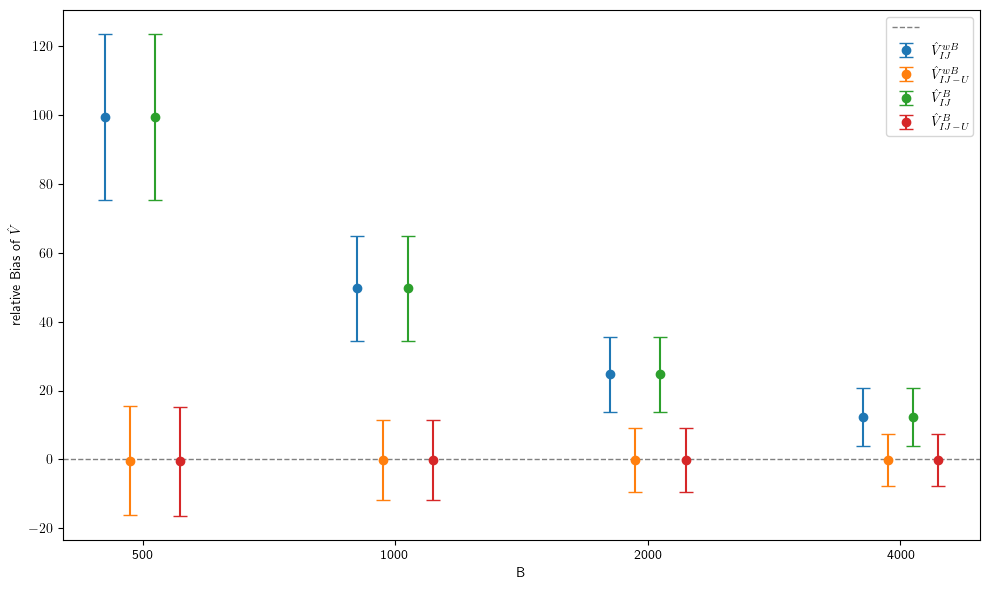

<Figure size 640x480 with 0 Axes>

In [65]:
import matplotlib.pyplot as plt

# Liste der B-Werte und Estimatoren
B_values = [500, 1000, 2000, 4000]
estimators = ['ijk_jahn', 'ijk_jahn_u', 'ijk_wager', 'ijk_wager_u']

# Dictionaries zur Speicherung der Mittelwerte und Standardabweichungen
mean_values = {est: [] for est in estimators}
std_values = {est: [] for est in estimators}

# CSV-Dateien laden und Kennzahlen berechnen
for B in B_values:
    df = pd.read_csv(f'simulation_results_B_{B}.csv')
    for est in estimators:
        mean_values[est].append(df[est].mean())
        std_values[est].append(df[est].std())

# X-Achse: Positionen für die verschiedenen B-Werte (als Index)
x = np.arange(len(B_values))
# Kleine horizontale Offsets, damit die Punkte der einzelnen Estimatoren nicht exakt übereinanderliegen
offsets = np.linspace(-0.15, 0.15, len(estimators))

plt.figure(figsize=(10, 6))
plt.rcParams["text.usetex"] = True

# Für jeden Estimator wird ein Punkt pro B-Wert mit Fehlerbalken gezeichnet
for i, est in enumerate(estimators):
    plt.errorbar(x + offsets[i], mean_values[est], yerr=std_values[est], fmt='o',
                 capsize=5, label=est)

# Horizontale Linie bei y = 0
plt.axhline(0, color='grey', linestyle='--', linewidth=1)

# X-Achsen-Beschriftungen auf die B-Werte setzen
plt.xticks(x, B_values)
plt.xlabel('B')
plt.ylabel('relative Bias of '+r'${\hat{V}}$')
plt.legend(['', r'${\hat{V}_{IJ}^{wB}}$'
    , r'${\hat{V}_{IJ-U}^{wB}}$'
    , r'${\hat{V}_{IJ}^{B}}$'
    , r'${\hat{V}_{IJ-U}^{B}}$' ])

plt.tight_layout()
plt.show()
plt.savefig('plot.png')
